In [246]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [247]:
train = pd.read_csv(r"D:\Prediction\Titanic Dataset for prediction model\train.csv")
test = pd.read_csv(r"D:\Prediction\Titanic Dataset for prediction model\test.csv")

In [248]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [249]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [250]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [251]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [252]:
train.shape

(891, 12)

In [253]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [254]:
### cabin has so much null values so we should remove this column from the dataset as it unecessary for the prediction.

In [255]:
train.drop(columns='Cabin',inplace=True)

In [256]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [257]:
test.shape

(418, 11)

In [258]:
test.drop(columns='Cabin',inplace=True)

In [259]:
### Separate the data into categorical and continuous 
train_num = train.select_dtypes(exclude=object)
train_obj = train.select_dtypes(include=object)
test_num = test.select_dtypes(exclude=object)
test_obj = test.select_dtypes(include=object)


In [260]:
### Handle the missing values of train data

In [261]:
## Handle missing values of numerical columns.
for i in train_num.columns:
    train[i] = train[i].fillna(train[i].median())
for i in test_num.columns:
    test[i] = test[i].fillna(train[i].median())

## ## Handle missing values of categorical columns.
for i in train_obj.columns:
    train[i] = train[i].fillna(train[i].mode()[0])
for i in test_obj.columns:
    test[i] = test[i].fillna(train[i].mode()[0])
    
    

In [262]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [263]:
### Outlier detection   by visual method(boxplot method)

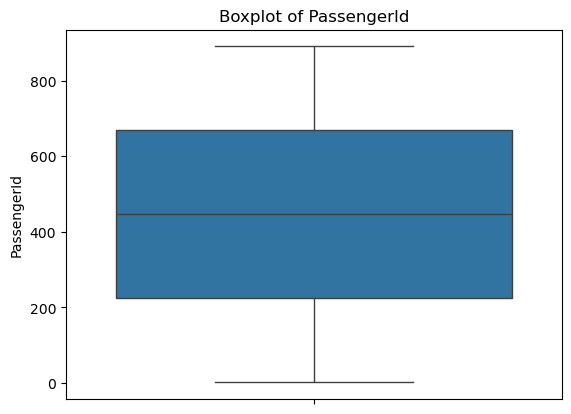

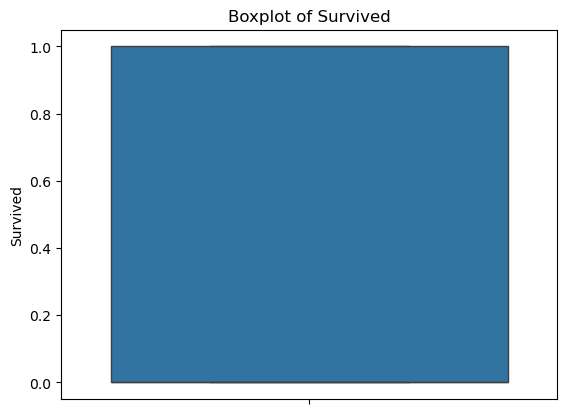

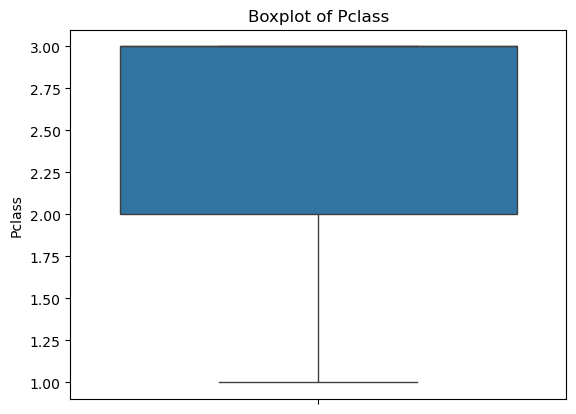

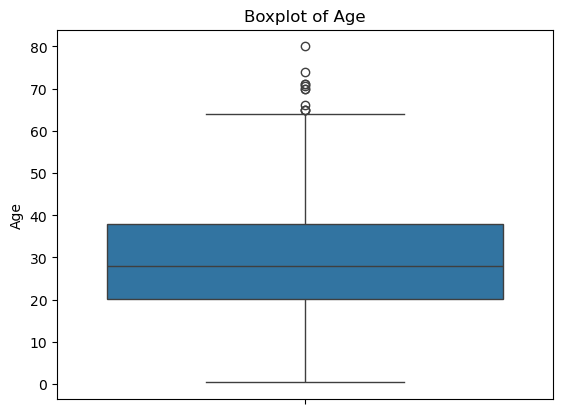

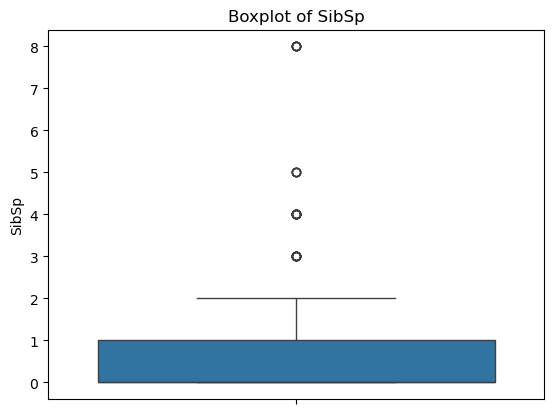

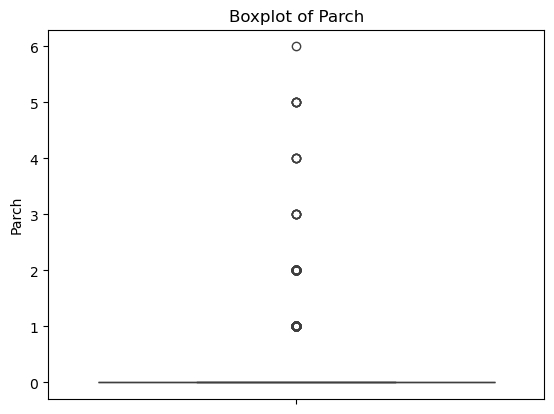

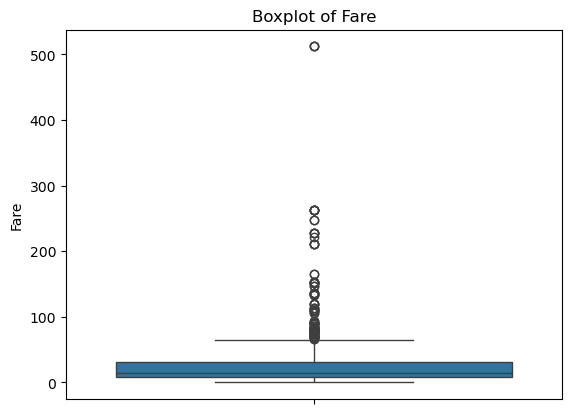

In [264]:
for col in train_num.columns:
   
    sns.boxplot(y=train_num[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [265]:
train_num.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [266]:
### outlier detection by virtual method     ### by IQR method.

In [267]:
col = ['Age','SibSp','Parch','Fare']
for i in col:
    q1 = train_num[i].quantile(0.25)
    q3 = train_num[i].quantile(0.75)
    iqr = q3-q1
    lw_ct = q1-1.5*iqr
    up_ct = q3+1.5*iqr
    print('No of',i, "Outliers:", train[(train[i] < lw_ct) | (train[i] > up_ct)].shape[0])

No of Age Outliers: 11
No of SibSp Outliers: 46
No of Parch Outliers: 213
No of Fare Outliers: 116


In [268]:
### By percentile method will calculate some serious outliers has present in it.
col = ['Age','SibSp','Parch','Fare']
for i in col:
    p1 = train_num[i].quantile(0.01)
    p75 = train_num[i].quantile(0.75)
    p90 = train_num[i].quantile(0.90)
    p95 = train_num[i].quantile(0.95)
    p99 = train_num[i].quantile(0.99)
    max = train_num[i].max()
    min = train_num[i].min()
    print(i," - ","Min -",min,'p1 -',p1,'p75 -',p75,'p90 -',p90,'p95 -',p95,'p99 -',p99,'Max -',max)

Age  -  Min - 0.42 p1 - 1.0 p75 - 38.0 p90 - 50.0 p95 - 56.0 p99 - 65.87 Max - 80.0
SibSp  -  Min - 0 p1 - 0.0 p75 - 1.0 p90 - 1.0 p95 - 3.0 p99 - 5.0 Max - 8
Parch  -  Min - 0 p1 - 0.0 p75 - 0.0 p90 - 2.0 p95 - 2.0 p99 - 4.0 Max - 6
Fare  -  Min - 0.0 p1 - 0.0 p75 - 31.0 p90 - 77.9583 p95 - 112.07915 p99 - 249.00622000000035 Max - 512.3292


In [269]:
### Note - No serious outliers are there in the column 'Age',SibSp,Parch
### change the fare column 

In [270]:
### outlier fixing for 'Fare' column.
train['Fare'] = train['Fare'].clip(upper=train['Fare'].quantile(0.99))


In [271]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [272]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [273]:
### Descriptive Analysis 
## Fare VS Age 

In [274]:
train.groupby('Age')['Fare'].sum()

Age
0.42       8.5167
0.67      14.5000
0.75      38.5166
0.83      47.7500
0.92     151.5500
           ...   
70.00     81.5000
70.50      7.7500
71.00     84.1584
74.00      7.7750
80.00     30.0000
Name: Fare, Length: 88, dtype: float64

<Axes: xlabel='Age', ylabel='Fare'>

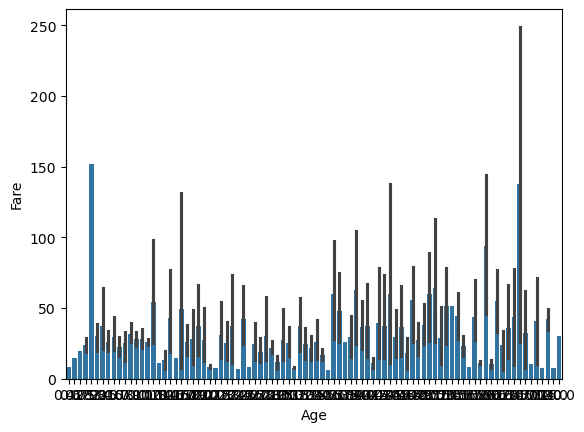

In [275]:
sns.barplot(train,x=train['Age'],y=train['Fare'])

In [276]:
train[train.Age < 10.1].Fare.sum()

np.float64(1947.8041)

In [277]:
train.Fare.sum()

np.float64(27821.267680000004)

In [278]:
train.Age.max()

80.0

In [279]:
train.Age.min()

0.42

In [280]:
train[train.Age < 1].shape   ### seven passengers are new born baby whose age is less than 1 year.

(7, 11)

In [281]:
train['bins']=pd.cut(train['Age'],bins=[0.1,10.1,20.1,30.1,40.1,50.1,60.1,70.1,80.1],labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80'],include_lowest=True)

In [282]:
train.groupby('bins')['Fare'].sum().sort_values(ascending=False)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10936\41043102.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('bins')['Fare'].sum().sort_values(ascending=False)


bins
20-30    10391.25526
30-40     5796.92656
40-50     3540.03360
10-20     3368.53354
0-10      1947.80410
50-60     1880.54170
60-70      766.48952
70-80      129.68340
Name: Fare, dtype: float64

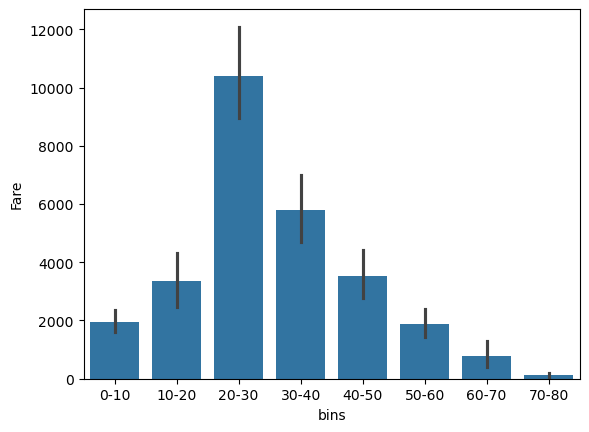

In [283]:
sns.barplot(x=train.bins,y=train.Fare,estimator=sum)
plt.show()

In [284]:
###   Approx 90% persons in the ship of the age between 10 to 50

In [285]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,bins
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,20-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,30-40
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,20-30
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,30-40
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,30-40


In [286]:
train.groupby('Parch')['PassengerId'].count()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: PassengerId, dtype: int64

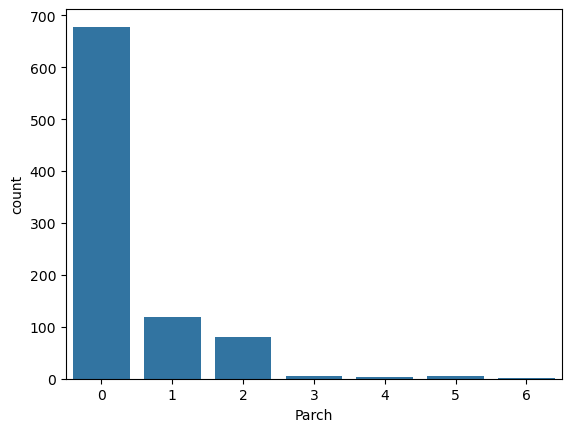

In [287]:
sns.countplot(train,x=train.Parch)
plt.show()

In [288]:
### Preparing the Model

In [289]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'bins'],
      dtype='object')

In [290]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [291]:
train_obj.columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

### Categorical encoding
* Make the dummy variables of the categorical columns.

In [292]:
train.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
bins           category
dtype: object

In [293]:
train.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True) ## drop the PassengerId , Name and Ticket column because it is uneccessary for creating the model.

In [294]:
train.dtypes

Survived       int64
Pclass         int64
Sex           object
Age          float64
SibSp          int64
Parch          int64
Fare         float64
Embarked      object
bins        category
dtype: object

In [295]:
## Now creating the dummy variables

In [296]:
train = pd.get_dummies(train,columns=['Sex','Embarked','bins'],drop_first=True)

In [297]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
 9   bins_10-20  891 non-null    bool   
 10  bins_20-30  891 non-null    bool   
 11  bins_30-40  891 non-null    bool   
 12  bins_40-50  891 non-null    bool   
 13  bins_50-60  891 non-null    bool   
 14  bins_60-70  891 non-null    bool   
 15  bins_70-80  891 non-null    bool   
dtypes: bool(10), float64(2), int64(4)
memory usage: 50.6 KB


In [298]:
### train and test split 

In [299]:
from sklearn.model_selection import train_test_split

In [300]:
train_1,test_1 = train_test_split(train,train_size=0.7,test_size=0.3,random_state=42)

In [301]:
train_1.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S', 'bins_10-20', 'bins_20-30', 'bins_30-40',
       'bins_40-50', 'bins_50-60', 'bins_60-70', 'bins_70-80'],
      dtype='object')

In [302]:
train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 445 to 102
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    623 non-null    int64  
 1   Pclass      623 non-null    int64  
 2   Age         623 non-null    float64
 3   SibSp       623 non-null    int64  
 4   Parch       623 non-null    int64  
 5   Fare        623 non-null    float64
 6   Sex_male    623 non-null    bool   
 7   Embarked_Q  623 non-null    bool   
 8   Embarked_S  623 non-null    bool   
 9   bins_10-20  623 non-null    bool   
 10  bins_20-30  623 non-null    bool   
 11  bins_30-40  623 non-null    bool   
 12  bins_40-50  623 non-null    bool   
 13  bins_50-60  623 non-null    bool   
 14  bins_60-70  623 non-null    bool   
 15  bins_70-80  623 non-null    bool   
dtypes: bool(10), float64(2), int64(4)
memory usage: 40.2 KB


In [303]:
## Now deleting the Age column because we already have bins column otherwise high multicolinarity occurred between bins and Age column as a result model get disrupted.

In [304]:
train_1.drop(columns='Age',inplace=True)

In [305]:
train_1.columns = train_1.columns.str.replace('-','_')

In [306]:
train_1.head()

,Survived,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,bins_10_20,bins_20_30,bins_30_40,bins_40_50,bins_50_60,bins_60_70,bins_70_80
445,1,1,0,2,81.8583,True,False,True,False,False,False,False,False,False,False
650,0,3,0,0,7.8958,True,False,True,False,True,False,False,False,False,False
172,1,3,1,1,11.1333,False,False,True,False,False,False,False,False,False,False
450,0,2,1,2,27.7500,True,False,True,False,False,True,False,False,False,False
314,0,2,1,1,26.2500,True,False,True,False,False,False,True,False,False,False


In [307]:
x = train_1.columns.difference(['Survived'])
x

Index(['Embarked_Q', 'Embarked_S', 'Fare', 'Parch', 'Pclass', 'Sex_male',
       'SibSp', 'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50',
       'bins_50_60', 'bins_60_70', 'bins_70_80'],
      dtype='object')

In [308]:
## Creating the Formula y ~ x1+x2+x3.....

### And Creating the model with all the features

In [309]:
formula_1 = 'Survived ~ ' + '+'.join(x)
formula_1

'Survived ~ Embarked_Q+Embarked_S+Fare+Parch+Pclass+Sex_male+SibSp+bins_10_20+bins_20_30+bins_30_40+bins_40_50+bins_50_60+bins_60_70+bins_70_80'

In [310]:
### Define and fit the model
import statsmodels.formula.api as smf
m1 = smf.logit(formula_1,train_1).fit()

Optimization terminated successfully.
         Current function value: 0.434006
         Iterations 7


In [311]:
print(m1.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.342     
Date:                 2026-06-07 12:37 AIC:              570.7710  
No. Observations:     623              BIC:              637.2892  
Df Model:             14               Log-Likelihood:   -270.39   
Df Residuals:         608              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      1.1726e-51
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           6.0323   0.7752   7.7812 0.0000  4.5129  7.5517
Embarked_Q[T.True] -0.2394   0.4504  -0.5315 0.5951 -1.1221  0.6434
Embarked_S[T.True] -0.7165   0.2904  -2.4674 0.0136 -1.2856 -0.1473
Sex_mal

In [312]:
## Note - Remove that column whose p-value > 0.10 , one by one.

In [313]:
## Feature Engineering 
### Now Remove the column bin_70_80 and create the second model.
x = x.difference(['bins_70_80'])
x


Index(['Embarked_Q', 'Embarked_S', 'Fare', 'Parch', 'Pclass', 'Sex_male',
       'SibSp', 'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50',
       'bins_50_60', 'bins_60_70'],
      dtype='object')

In [314]:
formula_2 = 'Survived ~ ' + '+'.join(x)
formula_2

'Survived ~ Embarked_Q+Embarked_S+Fare+Parch+Pclass+Sex_male+SibSp+bins_10_20+bins_20_30+bins_30_40+bins_40_50+bins_50_60+bins_60_70'

In [315]:
m2 = smf.logit(formula_2,train_1).fit()
m2

Optimization terminated successfully.
         Current function value: 0.435096
         Iterations 7


In [316]:
print(m2.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.340     
Date:                 2026-06-07 12:38 AIC:              570.1295  
No. Observations:     623              BIC:              632.2132  
Df Model:             13               Log-Likelihood:   -271.06   
Df Residuals:         609              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      4.7367e-52
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           5.8409   0.7514   7.7732 0.0000  4.3682  7.3137
Embarked_Q[T.True] -0.2813   0.4485  -0.6272 0.5305 -1.1603  0.5977
Embarked_S[T.True] -0.7266   0.2897  -2.5084 0.0121 -1.2944 -0.1589
Sex_mal

In [317]:
### Now Remove the column 'Fare' and create the Third model.

In [318]:
x

Index(['Embarked_Q', 'Embarked_S', 'Fare', 'Parch', 'Pclass', 'Sex_male',
       'SibSp', 'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50',
       'bins_50_60', 'bins_60_70'],
      dtype='object')

In [319]:
x= x.difference(['Fare'])
x

Index(['Embarked_Q', 'Embarked_S', 'Parch', 'Pclass', 'Sex_male', 'SibSp',
       'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50', 'bins_50_60',
       'bins_60_70'],
      dtype='object')

In [320]:
formula_3 = 'Survived ~ ' + '+'.join(x)
formula_3

'Survived ~ Embarked_Q+Embarked_S+Parch+Pclass+Sex_male+SibSp+bins_10_20+bins_20_30+bins_30_40+bins_40_50+bins_50_60+bins_60_70'

In [321]:
m3 = smf.logit(formula_3,train_1).fit()

Optimization terminated successfully.
         Current function value: 0.435779
         Iterations 7


In [322]:
print(m3.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.339     
Date:                 2026-06-07 12:38 AIC:              568.9800  
No. Observations:     623              BIC:              626.6291  
Df Model:             12               Log-Likelihood:   -271.49   
Df Residuals:         610              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      1.4434e-52
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           6.1378   0.6816   9.0049 0.0000  4.8019  7.4737
Embarked_Q[T.True] -0.2960   0.4486  -0.6598 0.5094 -1.1753  0.5833
Embarked_S[T.True] -0.7677   0.2855  -2.6888 0.0072 -1.3274 -0.2081
Sex_mal

In [323]:
### In model 2 AIC score is 552, and in model 3 AIC value decreased to 550 which means model is in the good direction.

In [324]:
x

Index(['Embarked_Q', 'Embarked_S', 'Parch', 'Pclass', 'Sex_male', 'SibSp',
       'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50', 'bins_50_60',
       'bins_60_70'],
      dtype='object')

In [325]:
### Now Remove the column 'Embarked_Q' and create the Fourth model.

In [326]:
x = x.difference(['Embarked_Q'])
x

Index(['Embarked_S', 'Parch', 'Pclass', 'Sex_male', 'SibSp', 'bins_10_20',
       'bins_20_30', 'bins_30_40', 'bins_40_50', 'bins_50_60', 'bins_60_70'],
      dtype='object')

In [327]:
formula_4 = 'Survived ~' + ' + '.join(x)
formula_4

'Survived ~Embarked_S + Parch + Pclass + Sex_male + SibSp + bins_10_20 + bins_20_30 + bins_30_40 + bins_40_50 + bins_50_60 + bins_60_70'

In [328]:
m4 = smf.logit(formula_4,train_1).fit()
m4

Optimization terminated successfully.
         Current function value: 0.436129
         Iterations 7


In [329]:
print(m4.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.339     
Date:                 2026-06-07 12:38 AIC:              567.4170  
No. Observations:     623              BIC:              620.6316  
Df Model:             11               Log-Likelihood:   -271.71   
Df Residuals:         611              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      3.4513e-53
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           6.0726   0.6716   9.0414 0.0000  4.7562  7.3890
Embarked_S[T.True] -0.6675   0.2417  -2.7609 0.0058 -1.1413 -0.1936
Sex_male[T.True]   -2.7794   0.2446 -11.3651 0.0000 -3.2587 -2.3001
bins_10

In [330]:
## Now remove the Parch column and creating the fifth Model 
x = x.difference(['Parch'])
x

Index(['Embarked_S', 'Pclass', 'Sex_male', 'SibSp', 'bins_10_20', 'bins_20_30',
       'bins_30_40', 'bins_40_50', 'bins_50_60', 'bins_60_70'],
      dtype='object')

In [331]:
formula_5 = 'Survived ~ ' + ' + '.join(x)
formula_5

'Survived ~ Embarked_S + Pclass + Sex_male + SibSp + bins_10_20 + bins_20_30 + bins_30_40 + bins_40_50 + bins_50_60 + bins_60_70'

In [332]:
m5 = smf.logit(formula_5,train_1).fit()
m5

Optimization terminated successfully.
         Current function value: 0.437662
         Iterations 7


In [333]:
print(m5.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.336     
Date:                 2026-06-07 12:39 AIC:              567.3265  
No. Observations:     623              BIC:              616.1065  
Df Model:             10               Log-Likelihood:   -272.66   
Df Residuals:         612              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      1.6075e-53
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           5.8701   0.6521   9.0013 0.0000  4.5919  7.1482
Embarked_S[T.True] -0.6880   0.2407  -2.8578 0.0043 -1.1598 -0.2161
Sex_male[T.True]   -2.6904   0.2336 -11.5145 0.0000 -3.1483 -2.2324
bins_10

In [334]:
### check after removing the Embarked_S column ,its effects the pseudoo r square and AIC or not 

In [335]:
v = x.difference(['Embarked_S'])
v

Index(['Pclass', 'Sex_male', 'SibSp', 'bins_10_20', 'bins_20_30', 'bins_30_40',
       'bins_40_50', 'bins_50_60', 'bins_60_70'],
      dtype='object')

In [336]:
formula_6 = 'Survived ~ ' + ' + '.join(v)
formula_6

'Survived ~ Pclass + Sex_male + SibSp + bins_10_20 + bins_20_30 + bins_30_40 + bins_40_50 + bins_50_60 + bins_60_70'

In [337]:
m6 = smf.logit(formula_6,train_1).fit()
m6

Optimization terminated successfully.
         Current function value: 0.444216
         Iterations 6


In [338]:
print(m6.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.326     
Date:                 2026-06-07 12:39 AIC:              573.4937  
No. Observations:     623              BIC:              617.8391  
Df Model:             9                Log-Likelihood:   -276.75   
Df Residuals:         613              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      1.5038e-52
No. Iterations:       6.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           5.4345   0.6250   8.6957 0.0000  4.2096  6.6594
Sex_male[T.True]   -2.7208   0.2327 -11.6934 0.0000 -3.1769 -2.2648
bins_10_20[T.True] -1.9526   0.5071  -3.8506 0.0001 -2.9465 -0.9587
bins_20

In [339]:
### AIC score increased in the model 6 as compared to model 5 , which is not good so we look forward with model 5

In [340]:
print(m5.summary2())

                          Results: Logit
Model:                Logit            Method:           MLE       
Dependent Variable:   Survived         Pseudo R-squared: 0.336     
Date:                 2026-06-07 12:39 AIC:              567.3265  
No. Observations:     623              BIC:              616.1065  
Df Model:             10               Log-Likelihood:   -272.66   
Df Residuals:         612              LL-Null:          -410.79   
Converged:            1.0000           LLR p-value:      1.6075e-53
No. Iterations:       7.0000           Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept           5.8701   0.6521   9.0013 0.0000  4.5919  7.1482
Embarked_S[T.True] -0.6880   0.2407  -2.8578 0.0043 -1.1598 -0.2161
Sex_male[T.True]   -2.6904   0.2336 -11.5145 0.0000 -3.1483 -2.2324
bins_10

In [341]:
### Now calulate the VIF 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [342]:
x_vif = train_1[x]
x_vif

,Embarked_S,Pclass,Sex_male,SibSp,bins_10_20,bins_20_30,bins_30_40,bins_40_50,bins_50_60,bins_60_70
445,True,1,True,0,False,False,False,False,False,False
650,True,3,True,0,False,True,False,False,False,False
172,True,3,False,1,False,False,False,False,False,False
450,True,2,True,1,False,False,True,False,False,False
314,True,2,True,1,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
106,True,3,False,0,False,True,False,False,False,False
270,True,1,True,0,False,True,False,False,False,False
860,True,3,True,2,False,False,False,True,False,False
435,True,1,False,1,True,False,False,False,False,False


In [343]:
x_vif.astype('int').head()


,Embarked_S,Pclass,Sex_male,SibSp,bins_10_20,bins_20_30,bins_30_40,bins_40_50,bins_50_60,bins_60_70
445,1,1,1,0,0,0,0,0,0,0
650,1,3,1,0,0,1,0,0,0,0
172,1,3,0,1,0,0,0,0,0,0
450,1,2,1,1,0,0,1,0,0,0
314,1,2,1,1,0,0,0,1,0,0


In [344]:
x_vif.shape[1]

10

In [345]:
x_vif = x_vif.astype('int')

In [346]:
x_vif.dtypes

Embarked_S    int64
Pclass        int64
Sex_male      int64
SibSp         int64
bins_10_20    int64
bins_20_30    int64
bins_30_40    int64
bins_40_50    int64
bins_50_60    int64
bins_60_70    int64
dtype: object

In [347]:
vif = pd.DataFrame()
vif['features'] = x
vif['VIF'] = [variance_inflation_factor(x_vif.values,i) for i in range(x_vif.shape[1])]


In [348]:
vif.sort_values(by='VIF',ascending=False)

,features,VIF
1,Pclass,7.156055
5,bins_20_30,3.765606
0,Embarked_S,3.723712
2,Sex_male,3.039661
6,bins_30_40,1.939202
4,bins_10_20,1.794843
7,bins_40_50,1.480518
3,SibSp,1.293430
8,bins_50_60,1.218267
9,bins_60_70,1.074850


In [349]:
# Note - VIF is for checking the multicolinarity between the columns. vif > 5 shows some multicolinarity.

In [350]:
## we Pclass because its p-value is 0 & we can say that its important for the prediction.

In [351]:
### Now do the prediction on the test_1

In [352]:
test_1.columns = test_1.columns.str.replace('-','_')

In [353]:
test_1.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S', 'bins_10_20', 'bins_20_30', 'bins_30_40',
       'bins_40_50', 'bins_50_60', 'bins_60_70', 'bins_70_80'],
      dtype='object')

In [354]:
test_1['y_pred_prob'] = m5.predict(test_1[x])

In [355]:
x

Index(['Embarked_S', 'Pclass', 'Sex_male', 'SibSp', 'bins_10_20', 'bins_20_30',
       'bins_30_40', 'bins_40_50', 'bins_50_60', 'bins_60_70'],
      dtype='object')

In [356]:
test_1.head(20)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,bins_10_20,bins_20_30,bins_30_40,bins_40_50,bins_50_60,bins_60_70,bins_70_80,y_pred_prob
709,1,3,28.0,1,1,15.2458,True,False,False,False,True,False,False,False,False,False,0.097954
439,0,2,31.0,0,0,10.5000,True,False,True,False,False,True,False,False,False,False,0.292164
840,0,3,20.0,0,0,7.9250,True,False,True,True,False,False,False,False,False,False,0.084019
720,1,2,6.0,0,1,33.0000,False,False,True,False,False,False,False,False,False,False,0.962972
39,1,3,14.0,1,0,11.2417,False,False,False,True,False,False,False,False,False,False,0.641915
290,1,1,26.0,0,0,78.8500,False,False,True,False,True,False,False,False,False,False,0.892031
300,1,3,28.0,0,0,7.7500,False,True,False,False,True,False,False,False,False,False,0.705969
333,0,3,16.0,2,0,18.0000,True,False,True,True,False,False,False,False,False,False,0.039153
208,1,3,16.0,0,0,7.7500,False,True,False,True,False,False,False,False,False,False,0.728965
136,1,1,19.0,0,2,26.2833,False,False,True,True,False,False,False,False,False,False,0.902485


In [357]:
y_pred = test_1['y_pred_prob'].apply(
    lambda x: 1 if x >= 0.5 else 0
)

In [358]:
y_pred

709    0
439    0
840    0
720    1
39     1
      ..
821    0
633    0
456    0
500    0
430    0
Name: y_pred_prob, Length: 268, dtype: int64

In [359]:
#### Accuracy check of the model by confusion_matrix, accuracy_score and classification_report

In [360]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

confusion_matrix(test_1['Survived'], y_pred)

accuracy_score(test_1['Survived'], y_pred)

print(classification_report(test_1['Survived'], y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       157
           1       0.77      0.77      0.77       111

    accuracy                           0.81       268
   macro avg       0.80      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [361]:
# find ROC_AOC 
from sklearn.metrics import roc_auc_score,roc_curve

In [362]:
y_pred_prob = m5.predict(test_1[x])

In [363]:
auc = roc_auc_score(test_1['Survived'], y_pred_prob)

auc

np.float64(0.8619670626040052)

In [364]:
fpr, tpr, threshold = roc_curve(
    test_1['Survived'],
    y_pred_prob
)

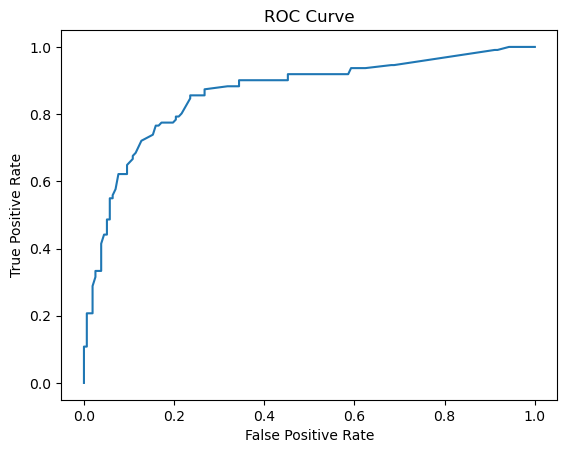

In [365]:
plt.plot(fpr,tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

In [366]:
somers_d = (2 * auc) - 1

somers_d

np.float64(0.7239341252080105)

In [367]:
## value of AUC is 0.86 and somars_d is 0.72 which conclude that model is working fine.


In [368]:
### Now apply the prediction on the test data.
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [369]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [370]:
test.shape

(418, 10)

In [371]:
test.nunique()

PassengerId    418
Pclass           3
Name           418
Sex              2
Age             79
SibSp            7
Parch            8
Ticket         363
Fare           169
Embarked         3
dtype: int64

In [372]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


In [373]:
passenger_id = test['PassengerId']
passenger_id

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [374]:
### drop the unrequired columns 
test.drop(columns=['PassengerId','Name','Ticket'],inplace=True)

In [375]:
test.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [376]:
### Make the bins of Age column 

In [377]:
test['bins']=pd.cut(test['Age'],bins=[0.1,10.1,20.1,30.1,40.1,50.1,60.1,70.1,80.1],labels=['0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80'],include_lowest=True)

In [378]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,bins
0,3,male,34.5,0,0,7.8292,Q,30-40
1,3,female,47.0,1,0,7.0000,S,40-50
2,2,male,62.0,0,0,9.6875,Q,60-70
3,3,male,27.0,0,0,8.6625,S,20-30
4,3,female,22.0,1,1,12.2875,S,20-30


In [379]:
test = pd.get_dummies(test,columns=['Sex','Embarked','bins'],drop_first=True)

In [380]:
test.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'bins_10-20', 'bins_20-30', 'bins_30-40', 'bins_40-50',
       'bins_50-60', 'bins_60-70', 'bins_70-80'],
      dtype='object')

In [381]:
### fix bins columnn naming convention --- replace '-' with '_'
test.columns = test.columns.str.replace('-','_')

In [382]:
test.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'bins_10_20', 'bins_20_30', 'bins_30_40', 'bins_40_50',
       'bins_50_60', 'bins_60_70', 'bins_70_80'],
      dtype='object')

In [383]:
### final_test
final_test = test[x]   ### x is the index of final model , we have to use same column throughwhich we created the model.
final_test

,Embarked_S,Pclass,Sex_male,SibSp,bins_10_20,bins_20_30,bins_30_40,bins_40_50,bins_50_60,bins_60_70
0,False,3,True,0,False,False,True,False,False,False
1,True,3,False,1,False,False,False,True,False,False
2,False,2,True,0,False,False,False,False,False,True
3,True,3,True,0,False,True,False,False,False,False
4,True,3,False,1,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
413,True,3,True,0,False,True,False,False,False,False
414,False,1,False,0,False,False,True,False,False,False
415,True,3,True,0,False,False,True,False,False,False
416,True,3,True,0,False,True,False,False,False,False


In [384]:
## Prediction Probability
final_prob = m5.predict(final_test)
final_prob

0      0.238887
1      0.388371
2      0.150617
3      0.075687
4      0.445768
         ...   
413    0.075687
414    0.969389
415    0.136253
416    0.075687
417    0.097954
Length: 418, dtype: float64

In [385]:
## convet probability into the 0 and 1 
final_pred = final_prob.apply(lambda x : 1 if x >= 0.5 else 0)
final_pred

0      0
1      0
2      0
3      0
4      0
      ..
413    0
414    1
415    0
416    0
417    0
Length: 418, dtype: int64

In [386]:
### Create Submission DataFrame
submission = pd.DataFrame({'Passengers_Id': passenger_id,'Survived':final_pred})
submission

,Passengers_Id,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [387]:
submission.to_csv('D:\Himanshu Projects\Prediction Model on Titanic Dataset\Survival_Prediction.csv',index = False)